In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Read Data
import pandas as pd
orders = pd.read_csv('/Users/fangyuan/Desktop/Olist_Pricing_Project/data/olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
base_path = '/Users/fangyuan/Desktop/Olist_Pricing_Project/data/' 

orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')

print("All data read successfully!")

All data read successfully!


In [ ]:
#Basic stitching and calculating delay days.
df_merged = pd.merge(orders, items, on='order_id', how='inner')

df_merged['order_estimated_delivery_date'] = pd.to_datetime(df_merged['order_estimated_delivery_date'])
df_merged['order_delivered_customer_date'] = pd.to_datetime(df_merged['order_delivered_customer_date'])

df_merged['Delay_Days'] = (df_merged['order_delivered_customer_date'] - df_merged['order_estimated_delivery_date']).dt.days

print("Delay days calculated!")

Delay days calculated!


In [ ]:
#Access rating and geographic location.
df_final = pd.merge(df_merged, reviews, on='order_id', how='inner')

df_geo = pd.merge(df_final, customers, on='customer_id', how='inner')

print(f"The large table has been built, totaling {df_geo.shape[0]} rows of data!")

The large table has been built, totaling 112372 rows of data!


In [ ]:
#Group by state.
state_analysis = df_geo.groupby('customer_state').agg({
    'Delay_Days': 'mean',       
    'freight_value': 'mean'     
}).reset_index()

#Data standardization by compressing days and money to between 0 and 1.
state_analysis['Delay_Norm'] = (state_analysis['Delay_Days'] - state_analysis['Delay_Days'].min()) / (state_analysis['Delay_Days'].max() - state_analysis['Delay_Days'].min())
state_analysis['Freight_Norm'] = (state_analysis['freight_value'] - state_analysis['freight_value'].min()) / (state_analysis['freight_value'].max() - state_analysis['freight_value'].min())

#Calculate the overall distress index (assuming: 70% anger about delays + 30% anger about shipping costs).
state_analysis['Pain_Index'] = state_analysis['Delay_Norm'] * 0.7 + state_analysis['Freight_Norm'] * 0.3

#Sort by misery index in descending order, find the top 5 worst states.
worst_states = state_analysis.sort_values(by='Pain_Index', ascending=False).head(5)

print("Top 5 Logistics Black Holes (Based on Misery Index)：")
print(worst_states[['customer_state', 'Delay_Days', 'freight_value', 'Pain_Index']])

Top 5 Logistics Black Holes (Based on Misery Index)：
   customer_state  Delay_Days  freight_value  Pain_Index
1              AL   -8.841121      35.724000    0.921755
9              MA  -10.110138      38.213572    0.875394
24             SE  -10.088472      36.194230    0.854881
16             PI  -11.510597      39.146766    0.804679
5              CE  -11.182584      32.765720    0.754828


In [ ]:
#Identifying high-risk users residing in the 5 worst-performing states.
target_states = worst_states['customer_state'].tolist()
at_risk_customers = df_geo[df_geo['customer_state'].isin(target_states)]

#Calculate Customer Lifetime Value (LTV).
customer_ltv = at_risk_customers.groupby('customer_unique_id').agg({
    'price': 'sum'            
}).reset_index()

#Sort by customer's historical total spending (price) in descending order.
customer_ltv = customer_ltv.sort_values(by='price', ascending=False)

#Budget constraint
BUDGET = 5000            
SUBSIDY_PER_USER = 50    
customers_saved = BUDGET // SUBSIDY_PER_USER

#Distribute subsidies to top users.
vip_subsidized = customer_ltv.head(customers_saved)

print(f"Within the budget of {BUDGET} BRL, we saved {len(vip_subsidized)} VIP customers.")
print(f"The potential revenue lost to be recovered is as high as: {vip_subsidized['price'].sum():.2f} BRL!")


Within the budget of 5000 BRL, we saved 100 VIP customers.
The potential revenue lost to be recovered is as high as: 120198.90 BRL!


In [9]:
%pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 7.1 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 14.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/cp/d_6mfkpx3gg4bgy4btk4ryr00000gn/T/ipykernel_1629/3567248061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_states, x='customer_state', y='Pain_Index', ax=axes[0], palette='Reds_r')
/var/folders/cp/d_6mfkpx3gg4bgy4btk4ryr00000gn/T/ipykernel_1629/3567248061.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strategy_data, x='Metric', y='Amount (BRL)', ax=axes[1], palette='Blues_d')


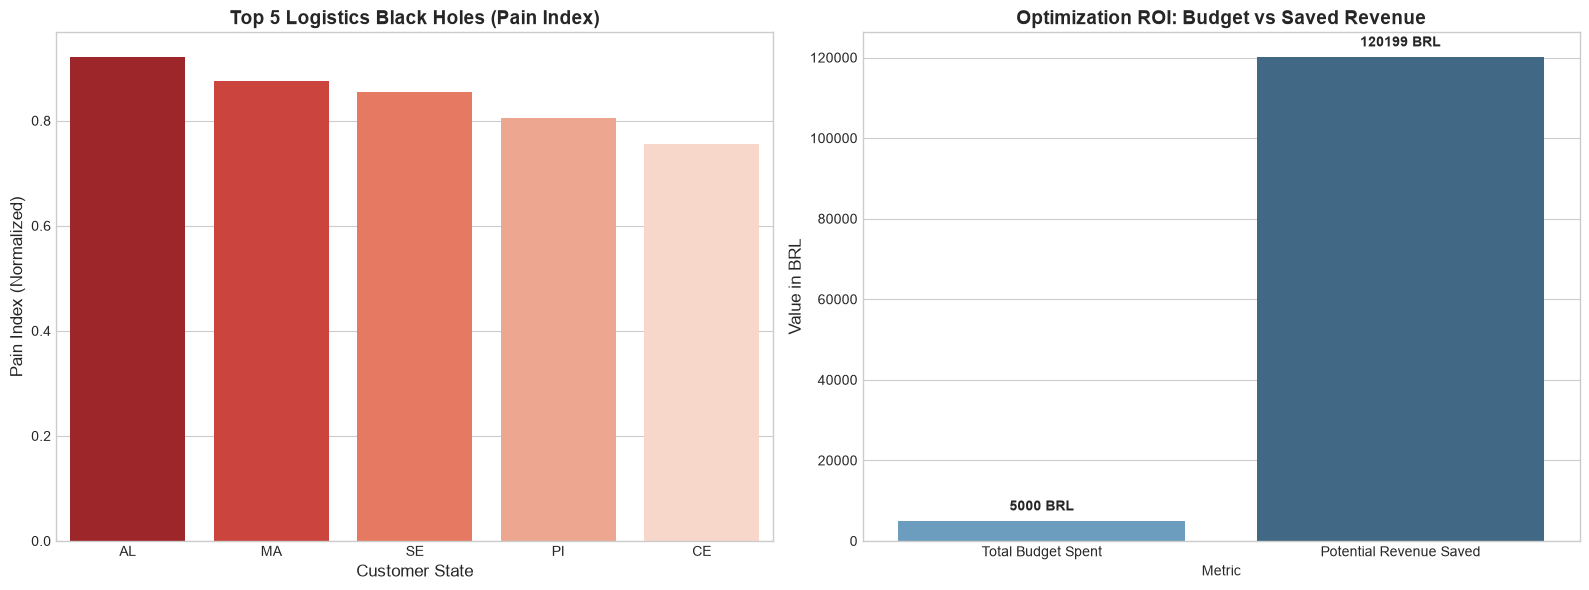

In [ ]:
#Visualization
lt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=worst_states, x='customer_state', y='Pain_Index', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 5 Logistics Black Holes (Pain Index)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer State', fontsize=12)
axes[0].set_ylabel('Pain Index (Normalized)', fontsize=12)

strategy_data = pd.DataFrame({
    'Metric': ['Total Budget Spent', 'Potential Revenue Saved'],
    'Amount (BRL)': [BUDGET, vip_subsidized['price'].sum()]
})
sns.barplot(data=strategy_data, x='Metric', y='Amount (BRL)', ax=axes[1], palette='Blues_d')
axes[1].set_title('Optimization ROI: Budget vs Saved Revenue', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Value in BRL', fontsize=12)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.0f} BRL", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()